<a href="https://colab.research.google.com/github/ncrowder/maven/blob/main/maven_drilll_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd

In [42]:
df = pd.read_csv(r'https://maven-datasets.s3.us-east-1.amazonaws.com/Data+Drills/coffee_shop_sales.csv',parse_dates=['date'])

In [43]:
df.head()

,order_id,date,store,product,quantity,sales
0,1,2023-01-01,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,2023-01-01,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,2023-01-01,Lower Manhattan,Hot chocolate,2,9.0
3,4,2023-01-01,Lower Manhattan,Drip coffee,1,2.0
4,5,2023-01-01,Lower Manhattan,Brewed Chai tea,2,6.2


In [44]:
df['month'] = df.date.dt.month
df['year'] = df.date.dt.year

In [45]:
df.groupby('store').value_counts(subset=['month','year'])

store            month  year
Astoria          6      2023    11985
                 5      2023    11475
                 4      2023     8556
                 3      2023     7180
                 1      2023     5913
                 2      2023     5490
Hell's Kitchen   6      2023    12071
                 5      2023    11294
                 4      2023     8629
                 3      2023     7267
                 1      2023     5868
                 2      2023     5606
Lower Manhattan  6      2023    11296
                 5      2023    10758
                 4      2023     8150
                 3      2023     6782
                 1      2023     5533
                 2      2023     5263
Name: count, dtype: int64

In [59]:
dfmonthly = df.groupby(['year','month','store'])[['quantity','sales']].sum().reset_index()
dfmonthly

,year,month,store,quantity,sales
0,2023,1,Astoria,8281,27313.66
1,2023,1,Hell's Kitchen,8340,27820.65
2,2023,1,Lower Manhattan,8249,26543.43
3,2023,2,Astoria,7718,25105.34
4,2023,2,Hell's Kitchen,7937,25719.80
5,2023,2,Lower Manhattan,7895,25320.05
6,2023,3,Astoria,9999,32835.43
7,2023,3,Hell's Kitchen,10198,33110.57
8,2023,3,Lower Manhattan,10209,32888.68
9,2023,4,Astoria,12026,39477.61


In [61]:
dfmonthly["diff_quantity"] = dfmonthly["quantity"] - dfmonthly.groupby("store")["quantity"].shift(1)
dfmonthly["diff_sales"] = dfmonthly["sales"] - dfmonthly.groupby("store")["sales"].shift(1)

In [62]:
dfmonthly

,year,month,store,quantity,sales,diff_quantity,diff_sales
0,2023,1,Astoria,8281,27313.66,NaN,NaN
1,2023,1,Hell's Kitchen,8340,27820.65,NaN,NaN
2,2023,1,Lower Manhattan,8249,26543.43,NaN,NaN
3,2023,2,Astoria,7718,25105.34,-563.0,-2208.32
4,2023,2,Hell's Kitchen,7937,25719.80,-403.0,-2100.85
5,2023,2,Lower Manhattan,7895,25320.05,-354.0,-1223.38
6,2023,3,Astoria,9999,32835.43,2281.0,7730.09
7,2023,3,Hell's Kitchen,10198,33110.57,2261.0,7390.77
8,2023,3,Lower Manhattan,10209,32888.68,2314.0,7568.63
9,2023,4,Astoria,12026,39477.61,2027.0,6642.18


## Three different ways to plot

In [63]:
import matplotlib.pyplot as plt

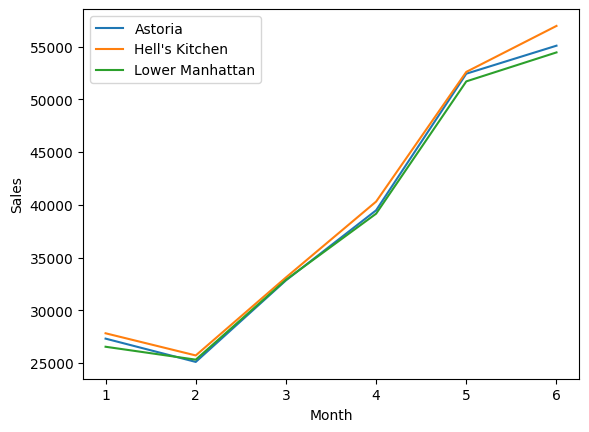

In [70]:
for store, group in dfmonthly.groupby("store"):
    plt.plot(group["month"], group["sales"], label=f"{store}")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend();

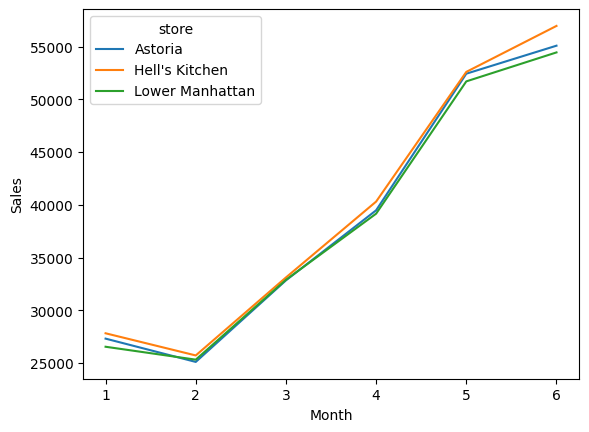

In [69]:
dfmonthly.pivot(index="month", columns="store", values="sales").plot(
    xlabel="Month",
    ylabel="Sales"
);

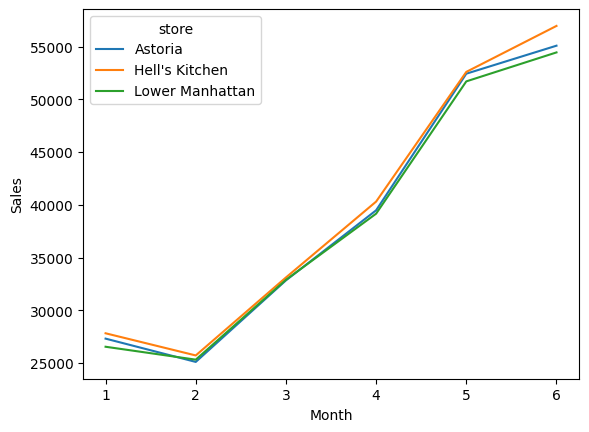

In [68]:
ax = dfmonthly.pivot(index="month", columns="store", values="sales").plot()
ax.set_xlabel("Month")
ax.set_ylabel("Sales");